In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [5]:
df = pd.read_csv('newborns_stats.csv')

In [6]:
df.isna().sum()

year      0
month     0
c1        2
cat1      0
target    0
dtype: int64

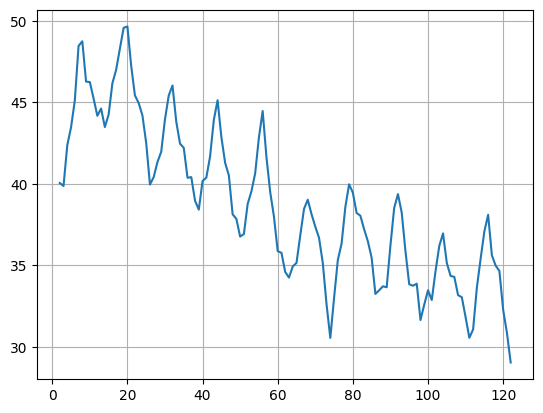

In [7]:
df['c1'].plot()
plt.grid()
plt.show()

In [8]:
df[['c1', 'cat1', 'target']].corr()

,c1,cat1,target
c1,1.000000,0.294024,0.883709
cat1,0.294024,1.000000,0.263559
target,0.883709,0.263559,1.000000


заполняем пропуски

In [12]:
first_valid = df['c1'].dropna().iloc[0]

df['c1'] = df['c1'].fillna(first_valid)

In [13]:
df['c1'].head(2)

0    40.045
1    40.045
Name: c1, dtype: float64

разбиваем датасет на обучающий и валидирующий

In [17]:
train = df.iloc[:-12]
val = df.iloc[-12:]

print(len(train))
print(len(val))

111
12


In [18]:
features = ['year', 'month', 'c1', 'cat1']

X_train = train[features]
y_train = train['target']

X_val = val[features]
y_val = val['target']

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)

mae = mean_absolute_error(y_val, pred_lr)
print(mae)

mape = mean_absolute_percentage_error(y_val, pred_lr)
print(f'{mape:.2%}')

731.4006773667643
8.07%


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)

mae = mean_absolute_error(y_val, pred_rf)
print(mae)

mape = mean_absolute_percentage_error(y_val, pred_rf)
print(f'{mape:.2%}')

685.8858333333332
8.24%


In [31]:
pd.Series(
    lr.coef_,
    index=features
).sort_values(key=abs, ascending=False)

cat1     240.968820
year    -188.148672
c1       176.784367
month    -35.795845
dtype: float64

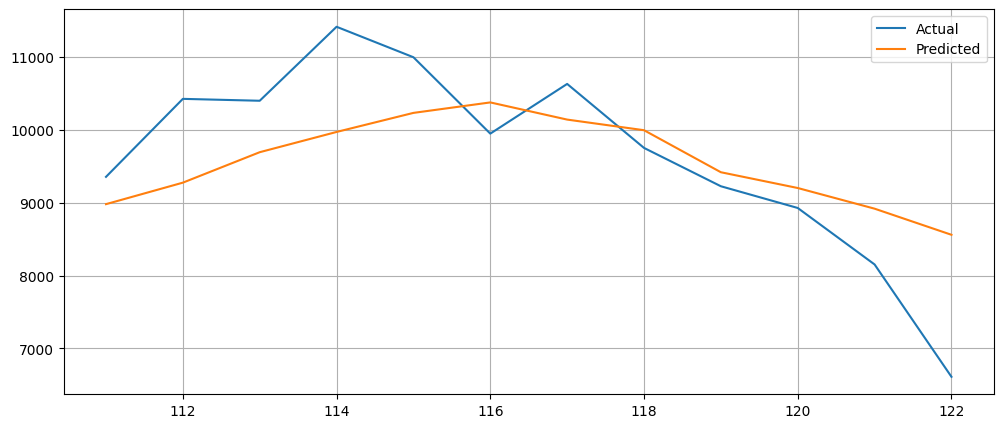

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(val.index, y_val, label='Actual')
plt.plot(val.index, pred_lr, label='Predicted')

plt.legend()
plt.grid()
plt.show()

In [33]:
df['lag1'] = df['target'].shift(1)
df['lag12'] = df['target'].shift(12)

In [ ]:
features = [
    'year',
    'month',
    'c1',
    'cat1',
    'lag1',
    'lag12'
]